In [150]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdulmalik1518/cars-datasets-2025")

print("Path to dataset files:", path)

Path to dataset files: /Users/linus/.cache/kagglehub/datasets/abdulmalik1518/cars-datasets-2025/versions/1


In [151]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

In [152]:
# List content of path
print("Content of dataset directory:")
import os
print(os.listdir(path))
# Load the dataset

Content of dataset directory:
['Cars Datasets 2025.csv']


In [153]:
df = pd.read_csv(path + "/Cars Datasets 2025.csv", encoding='latin1')

In [154]:
df

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm
...,...,...,...,...,...,...,...,...,...,...,...
1213,Toyota,Crown Signia,2.5L Hybrid I4,2487 cc,240 hp,180 km/h,7.6 sec,"$43,590  $48,000",Hybrid (Gas + Electric),5,239 Nm
1214,Toyota,4Runner (6th Gen),2.4L Turbo I4 (i-FORCE MAX Hybrid),2393 cc + Battery,326 hp,180 km/h,6.8 sec,"$50,000",Hybrid,7,630 Nm
1215,Toyota,Corolla Cross,2.0L Gas / 2.0L Hybrid,1987 cc / Hybrid batt,169  196 hp,190 km/h,8.0  9.2 sec,"$25,210  $29,135",Gas / Hybrid,5,190  210 Nm
1216,Toyota,C-HR+,1.8L / 2.0L Hybrid,1798 / 1987 cc + batt,140  198 hp,180 km/h,7.9  10.5 sec," 33,000",Hybrid,5,190  205 Nm


In [155]:
# Split 'HorsePower' column into two new columns
# This assumes 'HorsePower' is a string with a space separating the two values
# If 'HorsePower' is not a string, you may need to convert it first
# Split the 'HorsePower' column into one new column where values beofre the space are kept
df["HorsePower"] = df["HorsePower"].str.split(" ").str[0]
df["Torque"] = df["Torque"].str.split(" ").str[0]

In [156]:
# Convert hp and torque to numerics
df["HorsePower"] = pd.to_numeric(df["HorsePower"], errors="coerce")
df["Torque"]= pd.to_numeric(df["Torque"], errors="coerce")
df["Total_Speed"] = pd.to_numeric(df["Total Speed"].str.split(" ").str[0], errors="coerce")
df['Performance'] = pd.to_numeric(df["Performance(0 - 100 )KM/H"].str.split(" ").str[0], errors="coerce")

In [157]:
pd.to_numeric(df["Cars Prices"].str.split("$").str[1].replace(r"[^\d.]", "", regex=True))

0       1100000.0
1        460000.0
2         12000.0
3        161000.0
4        253290.0
          ...    
1213      43590.0
1214      50000.0
1215      25210.0
1216          NaN
1217      29000.0
Name: Cars Prices, Length: 1218, dtype: float64

In [158]:
# Remove everything that is not a number from the "Cars Prices" column

df["Price"] = pd.to_numeric(df["Cars Prices"].str.split("$").str[1].replace(r"[^\d.]", "", regex=True))

In [159]:
df = df.drop(["Cars Prices", "Total Speed", "Performance(0 - 100 )KM/H"], axis=1)

In [160]:
# EDA on dataset
df = df.dropna()

In [161]:
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
categoric_columns = df.select_dtypes(exclude=[np.number]).columns.tolist()

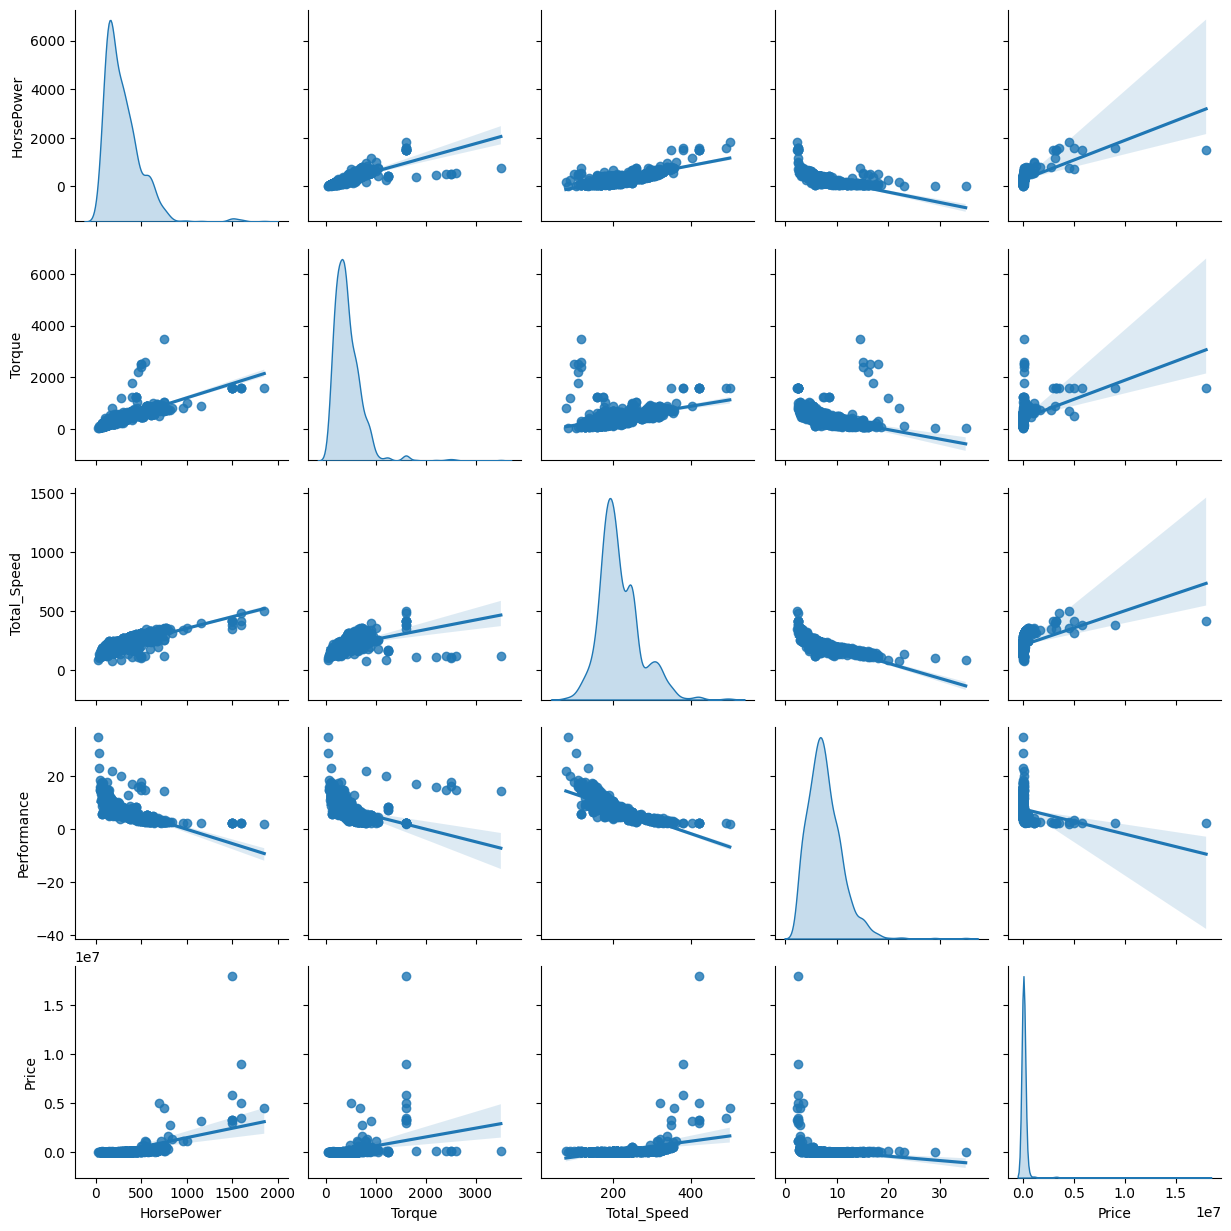

In [162]:
sns.pairplot(df[numeric_columns], diag_kind='kde', kind="reg")

In [163]:
df["Price"] = df[df["Price"] < 600000]["Price"]

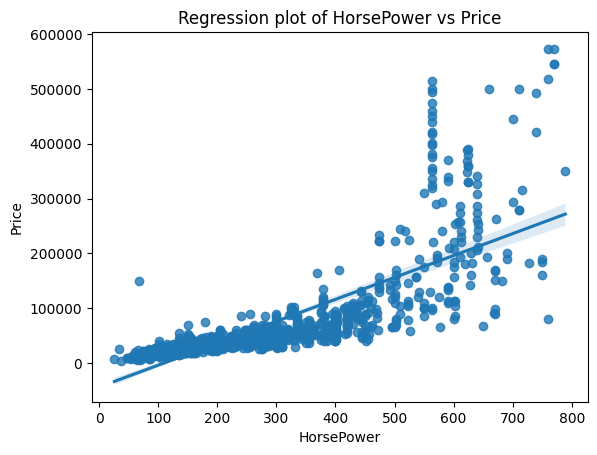

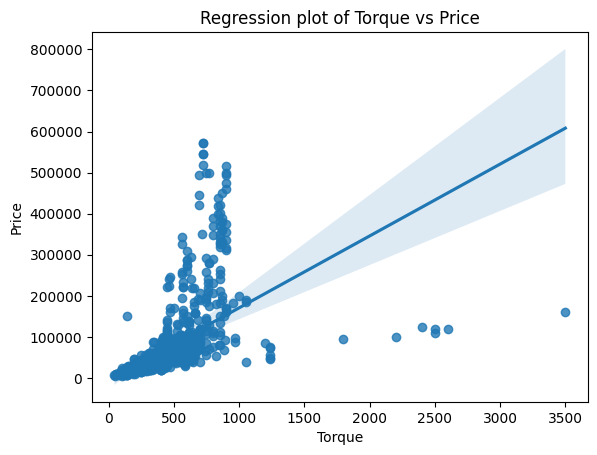

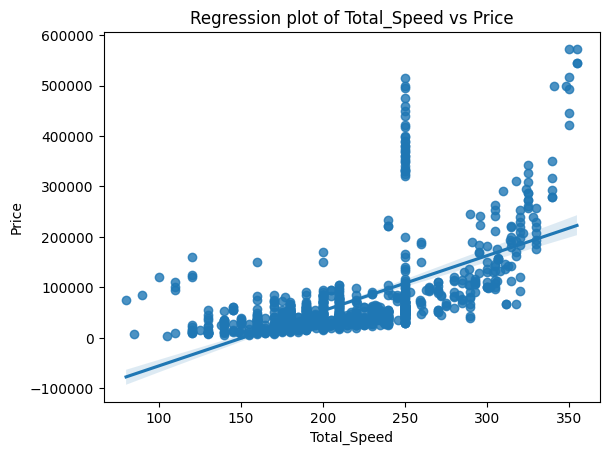

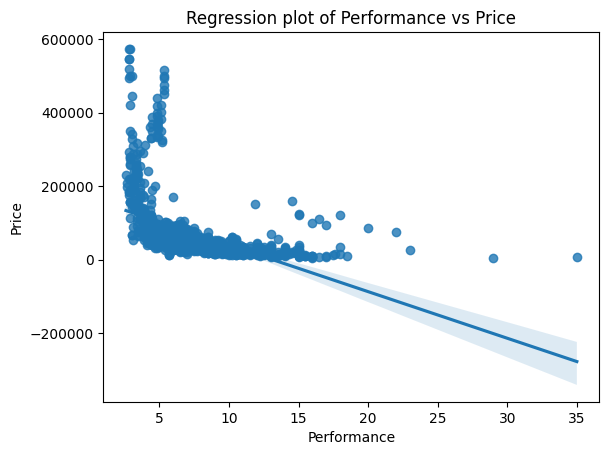

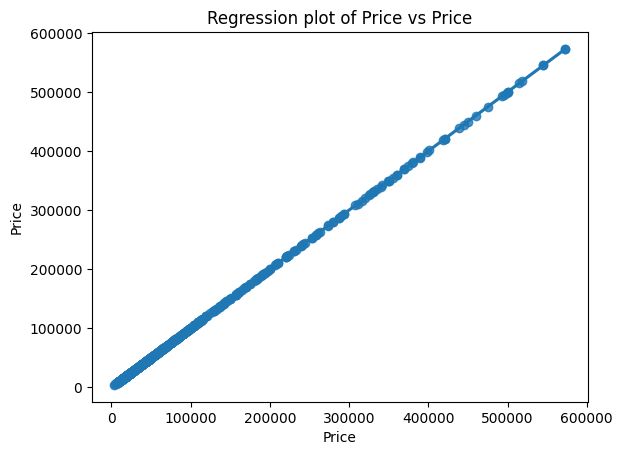

In [164]:
for col in numeric_columns:
    sns.regplot(x=col, y='Price', data=df)
    plt.title(f'Regression plot of {col} vs Price')
    plt.show()

In [165]:
df["log_price"] = np.log(df["Price"])

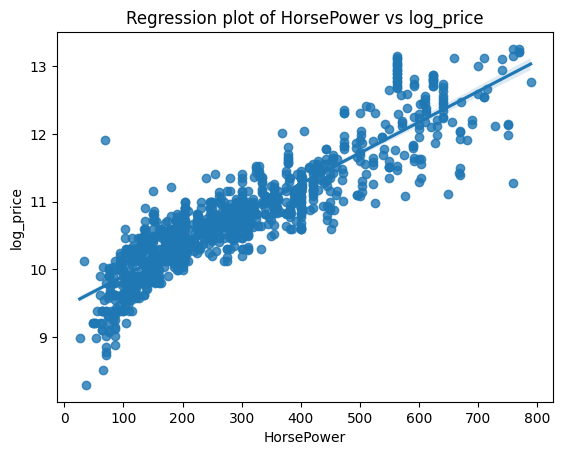

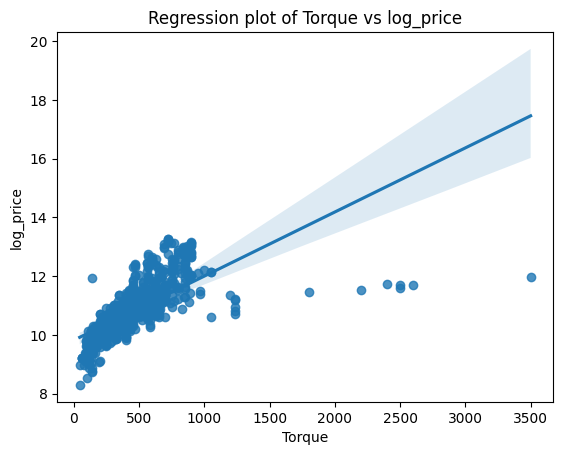

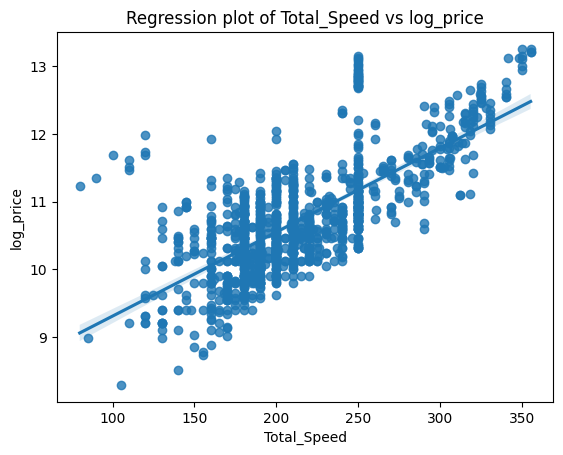

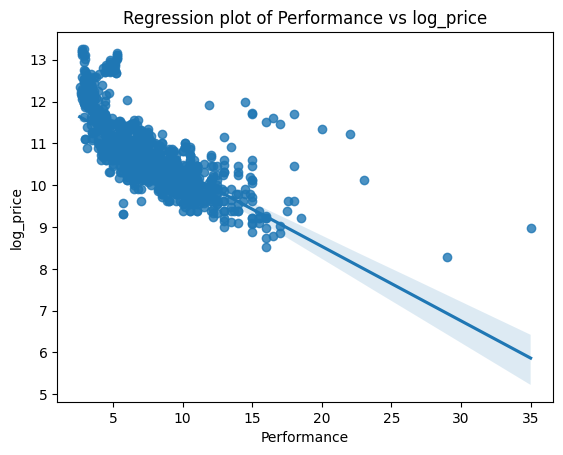

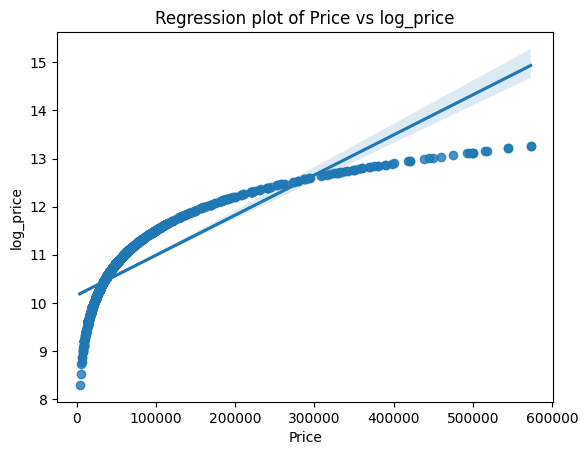

In [179]:
for col in numeric_columns:
    sns.regplot(x=col, y="log_price", data=df)
    plt.title(f'Regression plot of {col} vs log_price')
    plt.show()

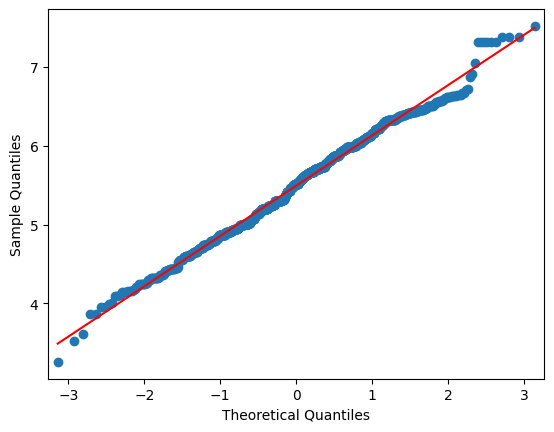

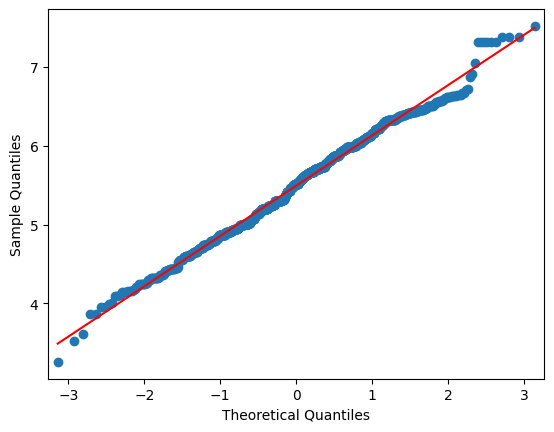

In [167]:
sm.qqplot(np.log(df["HorsePower"]), line='s')

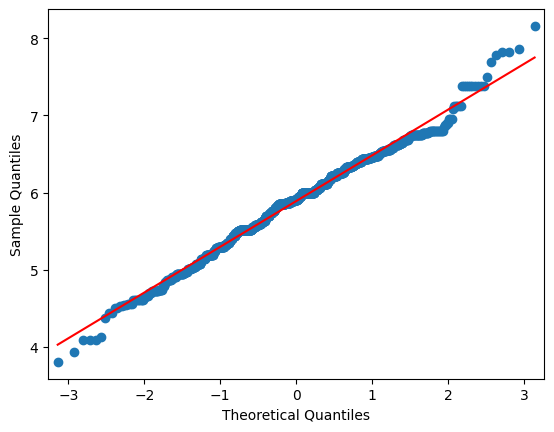

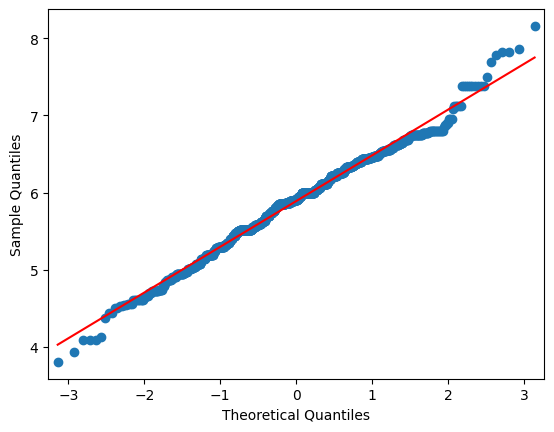

In [168]:
sm.qqplot(np.log(df["Torque"]), line='s')

In [169]:
df["log_HorsePower"] = np.log(df["HorsePower"])
df["log_Torque"] = np.log(df["Torque"])

<Axes: xlabel='Price', ylabel='Count'>

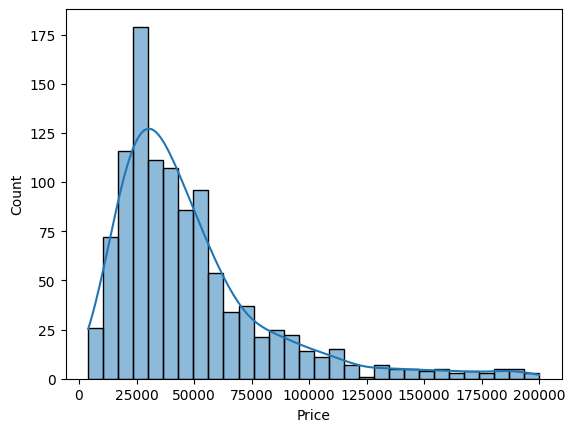

In [170]:
sns.histplot(df[df["Price"]<=200000]["Price"], kde=True)

<Axes: xlabel='log_price', ylabel='Count'>

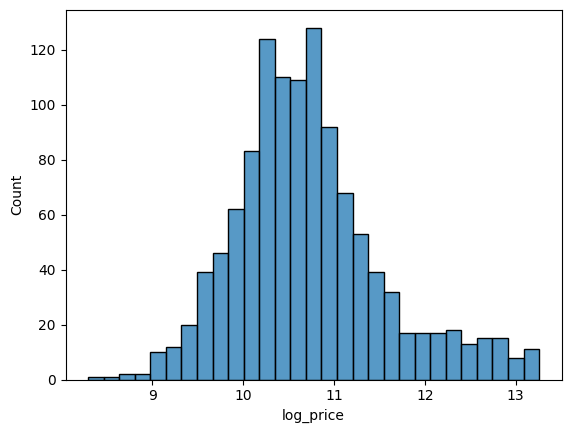

In [171]:
sns.histplot(df["log_price"])

In [210]:
# Encode dummy variables
from sklearn.model_selection import train_test_split

#DropNas
df = df.dropna()

X = df.drop("Price", axis=1)
y = df["Price"]

# Add intercept
X = sm.add_constant(X)

X_encoded = pd.get_dummies(X["Fuel Types"], prefix="Fuel ", dtype=int, drop_first=True)
X = pd.concat([X[["HorsePower", "Torque", "Total_Speed", "Performance"]], X_encoded], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Standardize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[["HorsePower", "Torque", "Total_Speed", "Performance"]] = scaler.fit_transform(X_train[["HorsePower", "Torque", "Total_Speed", "Performance"]])
X_test[["HorsePower", "Torque", "Total_Speed", "Performance"]] = scaler.transform(X_test[["HorsePower", "Torque", "Total_Speed", "Performance"]])

<Axes: >

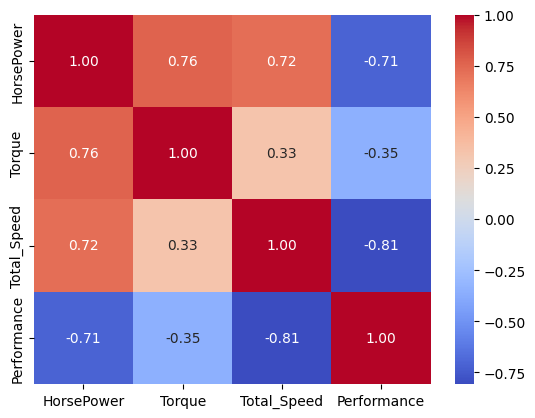

In [217]:
sns.heatmap(X_train[["HorsePower", "Torque", "Total_Speed", "Performance"]].corr(), annot=True, fmt=".2f", cmap="coolwarm")

In [204]:
y_train.isna().sum()

np.int64(0)

In [220]:
# OLS with log price
OLS_results = sm.OLS(np.log(y_train), X_train).fit_regularized(L1_wt=0.5, alpha=0.1)
#print(OLS_results.summary())
# Predictions
y_pred = OLS_results.predict(X_test)
# Evaluate predictions
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(np.log(y_test), y_pred)
r2 = r2_score(np.log(y_test), y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

Mean Squared Error: 8.931353812519042
R^2 Score: -12.488264449166577


In [230]:
y_train.isna().sum()

np.int64(0)

<Axes: ylabel='Count'>

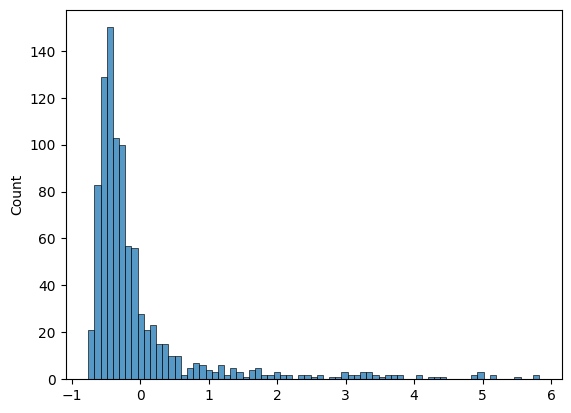

In [240]:
sns.histplot(stats.zscore(y_train))

<Axes: xlabel='Price', ylabel='Count'>

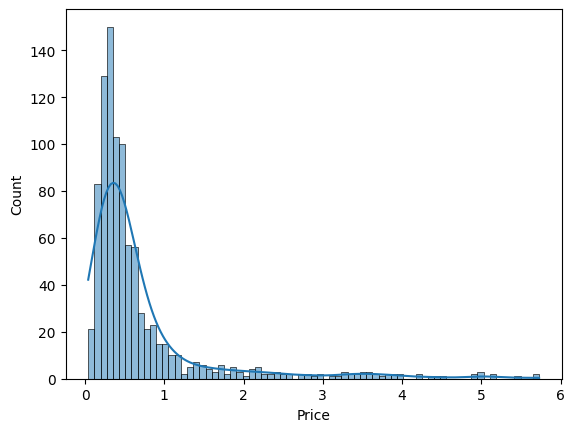

In [239]:
sns.histplot(y_train/100000, kde=True)

np.float64(5.824303714922854)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Price   No. Observations:                  931
Model:                            GLM   Df Residuals:                      908
Model Family:                   Gamma   Df Model:                           22
Link Function:                    Log   Scale:                         0.16995
Method:                          IRLS   Log-Likelihood:                 349.79
Date:                Fri, 25 Jul 2025   Deviance:                       111.55
Time:                        16:28:39   Pearson chi2:                     154.
No. Iterations:                    23   Pseudo R-squ. (CS):             0.9842
Covariance Type:            nonrobust                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
HorsePower    

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:521: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / np.sqrt(1 - self.hat_matrix_diag)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:1371: RuntimeWarning: invalid value encountered in sqrt
  beta_i /= np.sqrt(1 - self.hat_matrix_diag)


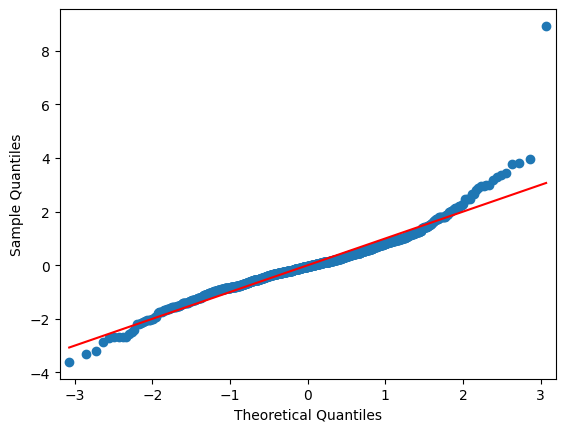

In [247]:
# Build Gamma GLM
gamma_glm = sm.GLM(y_train/100000, X_train, family=sm.families.Gamma(link=sm.families.links.Log()))
gamma_results = gamma_glm.fit()
print(gamma_results.summary())

# Plot deviance residuals
residuals = stats.zscore(gamma_results.resid_deviance)
sm.qqplot(residuals, line='s')

# Identify cooks distance outliers
influence = gamma_results.get_influence().summary_frame()
cooks_d = influence['cooks_d'].sort_values(ascending=False)

In [251]:
X_train.loc[cooks_d[cooks_d > 4 / len(X_train)].sort_values(ascending=False).head(5).index, :]

,HorsePower,Torque,Total_Speed,Performance,Fuel _Diesel,Fuel _Diesel/Petrol,Fuel _Electric,Fuel _Gas / Hybrid,Fuel _Hybrid,Fuel _Hybrid (Gas + Electric),Fuel _Hybrid (Petrol),Fuel _Hybrid / Plug-in,Fuel _Hybrid/Electric,Fuel _Hybrid/Petrol,Fuel _Hydrogen,Fuel _Petrol,"Fuel _Petrol, Diesel","Fuel _Petrol, Hybrid",Fuel _Petrol/AWD,Fuel _Petrol/Diesel,Fuel _Petrol/EV,Fuel _Petrol/Hybrid,Fuel _Plug-in Hybrid
265,-0.872955,-0.451840,-1.154561,0.253076,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1217,-0.386703,-0.721819,-0.308336,-0.511507,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
350,-1.304503,-1.017336,-1.154561,1.292908,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
300,-0.806095,-0.251180,-0.519892,0.528326,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
898,-0.623751,1.390582,-2.847012,4.381822,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [256]:
df.loc[cooks_d[cooks_d > 4 / len(X_train)].sort_values(ascending=False).head(5).index]

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Fuel Types,Seats,Torque,Total_Speed,Performance,Price,log_price,log_HorsePower,log_Torque
265,HYUNDAI,Ioniq,1.6L Inline-4,"1,600 cc",139.0,Hybrid/Electric,5,295.0,160,8.5,18000.0,9.798127,4.934474,5.686975
1217,Toyota,RAV4 (6th Gen),2.5L Hybrid / Plug-in Hybrid,2487 cc + batt,219.0,Hybrid / Plug-in,5,221.0,200,6.0,29000.0,10.275051,5.389072,5.398163
350,Volkswagen,Volkswagen XL1,Plug-in Hybrid (0.8L I2 Diesel),800 cc + Electric Motor,68.0,Hybrid,2,140.0,160,11.9,150000.0,11.918391,4.219508,4.941642
300,Volkswagen,Multivan,Plug-in Hybrid / Diesel I4,1395 cc / 1968 cc,150.0,"Petrol, Hybrid",7,350.0,190,9.4,50000.0,10.819778,5.010635,5.857933
898,Volvo,Volvo FL,5.1L I4 Turbo Diesel,5100 cc,180.0,Diesel,2,800.0,80,22.0,75000.0,11.225243,5.192957,6.684612


In [257]:
X_train_robust = X_train.drop(cooks_d[cooks_d > 4 / len(X_train)].sort_values(ascending=False).head(5).index)
y_train_robust = y_train.drop(cooks_d[cooks_d > 4 / len(X_train)].sort_values(ascending=False).head(5).index)
# Refit the model without outliers
gamma_glm_robust = sm.GLM(y_train_robust/100000, X_train_robust, family=sm.families.Gamma(link=sm.families.links.Log()))
gamma_results_robust = gamma_glm_robust.fit()
print(gamma_results_robust.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Price   No. Observations:                  926
Model:                            GLM   Df Residuals:                      905
Model Family:                   Gamma   Df Model:                           20
Link Function:                    Log   Scale:                         0.11999
Method:                          IRLS   Log-Likelihood:                 423.18
Date:                Fri, 25 Jul 2025   Deviance:                       99.953
Time:                        16:32:24   Pearson chi2:                     109.
No. Iterations:                    23   Pseudo R-squ. (CS):             0.9975
Covariance Type:            nonrobust                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
HorsePower    

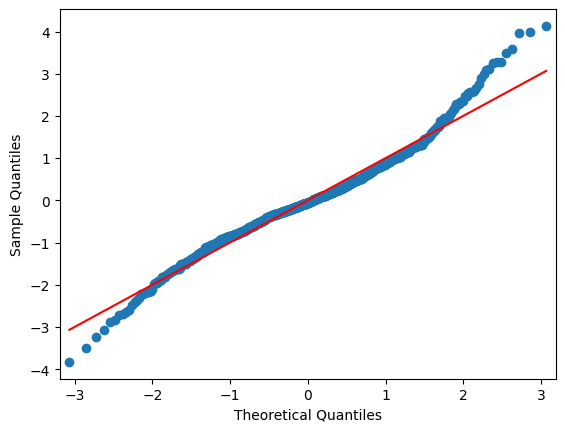

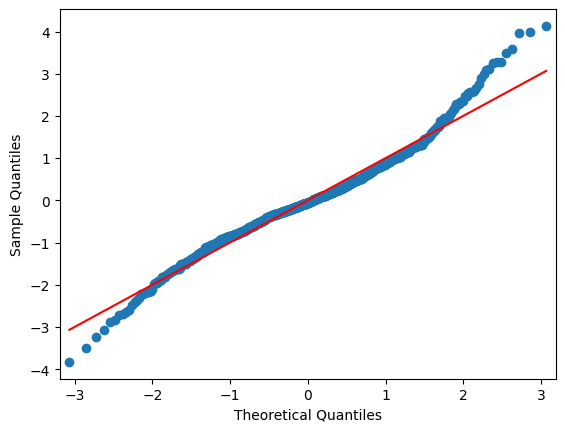

In [258]:
sm.qqplot(stats.zscore(gamma_results_robust.resid_deviance), line='s')

In [233]:
# Build GLM for lognormal price
LogNormal = sm.GLM(y_train, X_train, family=sm.families.Gaussian(link=sm.families.links.Log()))
LogNormal_results = LogNormal.fit()
print(LogNormal_results.summary())

# Evaluation
from sklearn.metrics import mean_squared_error, r2_score
y_pred = LogNormal_results.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"Mean Absolute Percentage Error: {mape:.2f}%")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")
# Plotting the residuals

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Price   No. Observations:                  931
Model:                            GLM   Df Residuals:                      908
Model Family:                Gaussian   Df Model:                           22
Link Function:                    Log   Scale:                      2.0134e+09
Method:                          IRLS   Log-Likelihood:                -11282.
Date:                Fri, 25 Jul 2025   Deviance:                   1.8282e+12
Time:                        16:11:34   Pearson chi2:                 1.83e+12
No. Iterations:                    41   Pseudo R-squ. (CS):             0.9351
Covariance Type:            nonrobust                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
HorsePower    

In [234]:
# XGBoost Regression
from xgboost import XGBRegressor
xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1)
xgb_model.fit(X_train, y_train)
# Predictions
y_pred_xgb = xgb_model.predict(X_test)
# Evaluate predictions
from sklearn.metrics import mean_squared_error, r2_score
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100
print(f'Mean Absolute Percentage Error (XGBoost): {mape_xgb:.2f}%')
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f'XGBoost Mean Squared Error: {mse_xgb}')
print(f'XGBoost R^2 Score: {r2_xgb}')
# Feature Importance

Mean Absolute Percentage Error (XGBoost): 18.10%
XGBoost Mean Squared Error: 459056196.1906323
XGBoost R^2 Score: 0.926660888582289


In [224]:
# FIt LightGBM
import lightgbm as lgb

model = lgb.LGBMRegressor(
    objective='regression',
    boosting_type='gbdt',
    num_leaves=31,
    learning_rate=0.1,
    n_estimators=1000,
    random_state=42
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)])
# Predictions
y_pred = model.predict(X_test, num_iteration=model.best_iteration)
# Evaluate predictions
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

[LightGBM] [Fatal] Do not support special JSON characters in feature name.


LightGBMError: Do not support special JSON characters in feature name.